1. Скачайте датасет по ссылке.

2. Постройте модель с логистическим трендом с уровнем вместимости 9 и добавьте учёт праздников США.

3. Постройте прогноз на год вперед и отобразите его вместе с точками перемены тренда.

4. Домашку можно выполнять в тетрадке jupyter, любой IDE для python или в онлайн-среде вроде google colab. 

5. На проверку отправьте jupyter notebook, файл с кодом для выполнения/отрисовки,  либо ссылку на соответствующую онлайн-тетрадку.

In [1]:
!pip install prophet
!pip install matplotlib pandas

     ---------------------------------------- 0.0/50.0 kB ? eta -:--:--
     --------------- ---------------------- 20.5/50.0 kB 640.0 kB/s eta 0:00:01
     -------------------------------------- 50.0/50.0 kB 846.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.2/12.1 MB 5.3 MB/s eta 0:00:03
   -- ------------------------------------- 0.6/12.1 MB 7.9 MB/s eta 0:00:02
   ------- -------------------------------- 2.2/12.1 MB 17.2 MB/s eta 0:00:01
   ---------------------- ----------------- 6.8/12.1 MB 39.4 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 108.8 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 93.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/99.1 kB ? eta -:--:--
   ---------------------------------------- 99.1/99.1 kB 5.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------

In [2]:
import pandas as pd
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("wp_log_R.csv")

df["cap"] = 9

df.head()

,ds,y,cap
0,2008-01-30,5.976351,9
1,2008-01-16,6.049733,9
2,2008-01-17,6.011267,9
3,2008-01-14,5.953243,9
4,2008-01-15,5.910797,9


In [4]:
from prophet.make_holidays import make_holidays_df

years = range(df["ds"].astype(str).str[:4].astype(int).min(),
              df["ds"].astype(str).str[:4].astype(int).max() + 2)

holidays = make_holidays_df(year_list=years, country="US")

model = Prophet(
    growth="logistic",
    holidays=holidays
)

model.fit(df)

12:03:52 - cmdstanpy - INFO - Chain [1] start processing
12:03:52 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
future = model.make_future_dataframe(periods=365)
future["cap"] = 9

forecast = model.predict(future)

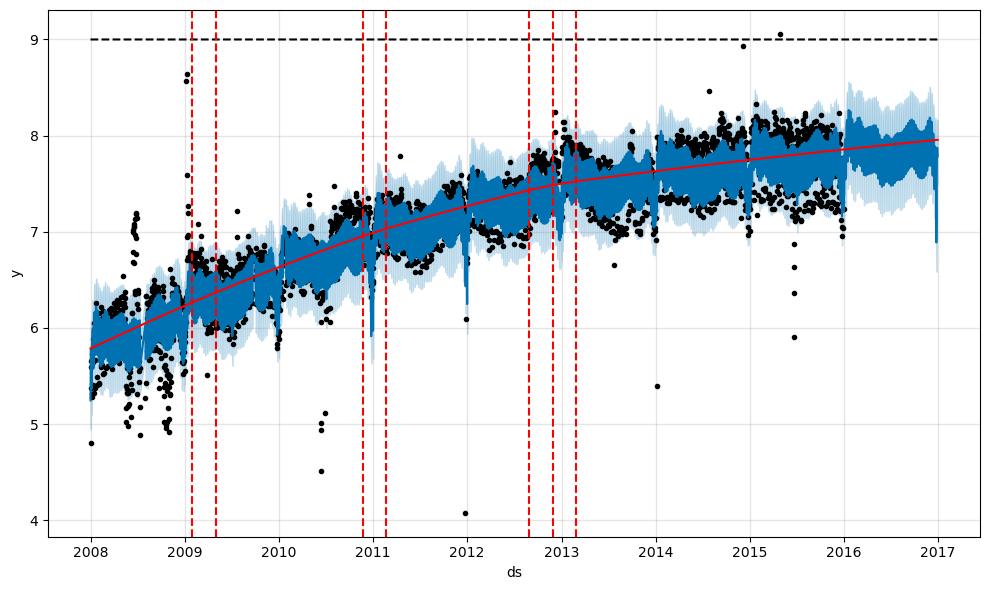

In [6]:
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast)
plt.show()